District_Name
The Golden Reef    72.874662
Coral Slums        66.474728
Deep Trench        63.266610
Mariana Plaza      63.245670
Name: Commutes_Out, dtype: float64


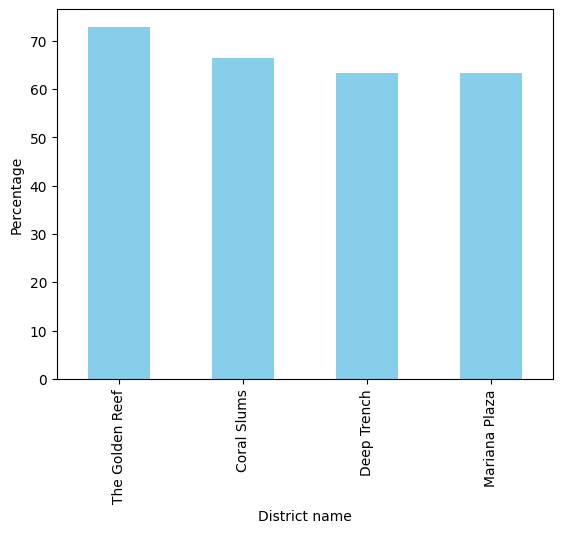

Occupation
Miner       70.178336
Fisher      69.483418
Merchant    67.609618
Warrior     65.137355
Scribe      60.809203
Name: Commutes_Out, dtype: float64


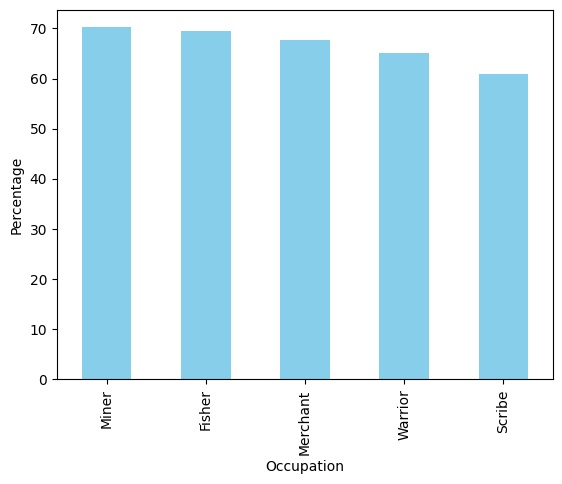

District_Name
The Golden Reef    84364728.0
Mariana Plaza      24906746.0
Deep Trench        20952823.0
Coral Slums         9824301.0
Name: Wealth_Index, dtype: float64


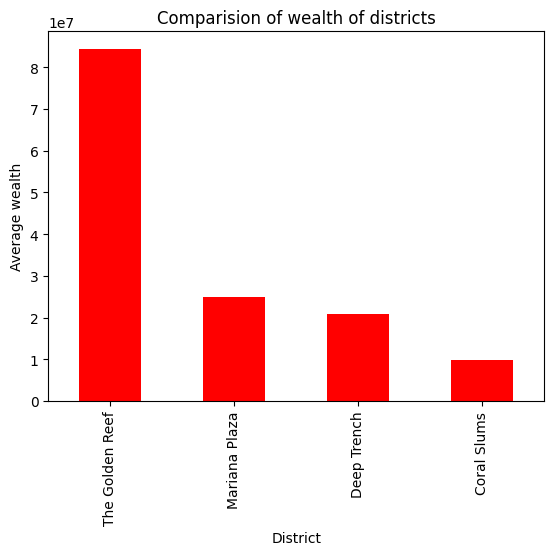

The average citizen in the richest district compared to the poorest is 589.377 times wealthier


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('atlantis_citizens_final.csv')
#Q1
df['Commutes_Out']= df['District_Name']!=df['Work_District']
x = df.groupby('District_Name')['Commutes_Out'].mean().sort_values(ascending=False)*100
print(x)
x.plot(kind = 'bar', color = 'skyblue',ylabel = 'Percentage',xlabel = 'District name')
plt.show()
y = df.groupby('Occupation')['Commutes_Out'].mean().sort_values(ascending = False)*100
print(y)
y.plot(kind = 'bar', color = 'skyblue', ylabel = 'Percentage',xlabel = 'Occupation')
plt.show()
#Q2
z = df.groupby('District_Name')['Wealth_Index'].sum().sort_values(ascending = False)
print(z)
z.plot(kind = 'bar', color = 'red',ylabel = 'Average wealth',xlabel = 'District',title = 'Comparision of wealth of districts')
plt.show()
ratio = df['Wealth_Index'].max()/df['Wealth_Index'].min()
print(f"The average citizen in the richest district compared to the poorest is {ratio} times wealthier")



Mathematical Proof: With a Correlation Coefficient of 0.80, there is a strong positive dependency between House Size and Life Expectancy, proving that as house size increases, longevity typically follows.


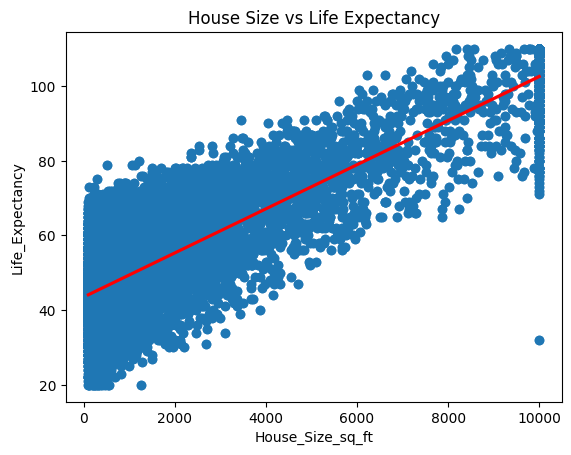

In [44]:
#Q3
import seaborn as sns 
plt.scatter(df['House_Size_sq_ft'], df['Life_Expectancy'])
plt.title('House Size vs Life Expectancy')
plt.xlabel('House Size (sq ft)')
plt.ylabel('Life Expectancy')
sns.regplot(data=df, x='House_Size_sq_ft', y='Life_Expectancy', line_kws={'color':'red'}) 
print(f"Mathematical Proof: With a Correlation Coefficient of {correlation_house_life:.2f}, there is a strong positive dependency between House Size and Life Expectancy, proving that as house size increases, longevity typically follows.")

<Axes: xlabel='Diet_Type', ylabel='Wealth_Index'>

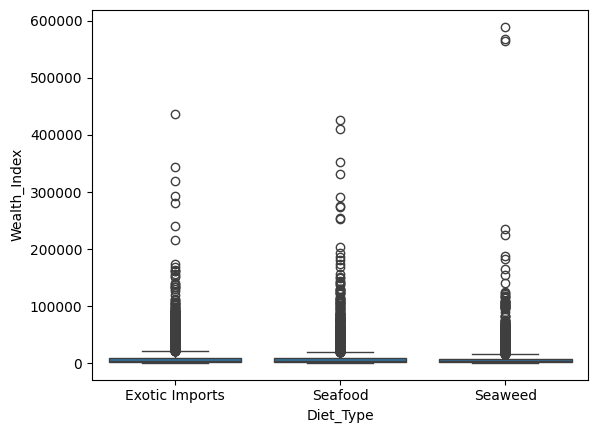

In [58]:
#Q4
sns.boxplot(data=df, x='Diet_Type', y='Wealth_Index')

Occupation
Fisher      [72, 80, a2, 1a, d2, fd, 23, 4d, c4, 1b, e0, 9...
Merchant    [70, 54, 47, 61, cc, f7, ad, 5f, bb, a4, 68, 9...
Miner       [7b, ad, 89, c4, 10, 77, cd, e8, e0, 3a, c2, 8...
Scribe      [b8, 6e, 2a, 4e, e0, e4, a9, f6, 56, 4c, 3a, 9...
Warrior     [0a, c7, e4, ad, 51, 1c, 8f, f4, 06, 41, ae, e...
Name: Hash_Prefix, dtype: object


<Axes: title={'center': 'Unique Bio-Hashes per Occupation'}, xlabel='Occupation'>

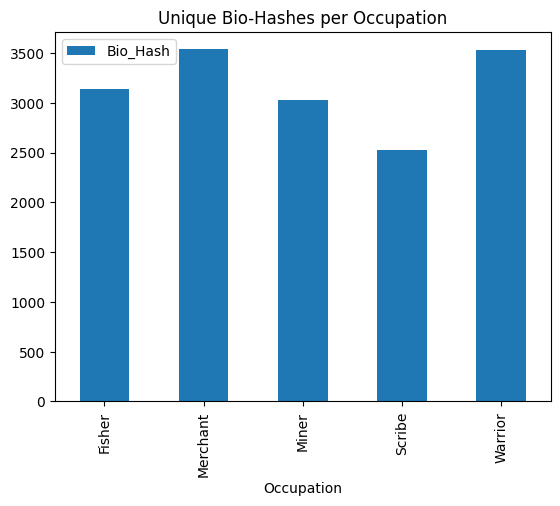

In [63]:
#Q5
df['Hash_Prefix'] = df['Bio_Hash'].str[:2]
pattern_check = df.groupby('Occupation')['Hash_Prefix'].unique()
print(pattern_check)
b = df.groupby('Occupation')['Bio_Hash'].nunique().reset_index()
b.plot(kind='bar', x='Occupation', y='Bio_Hash', title='Unique Bio-Hashes per Occupation')

<Axes: title={'center': 'Relation between wealth and occupation'}, xlabel='Occupation', ylabel='Avg wealth'>

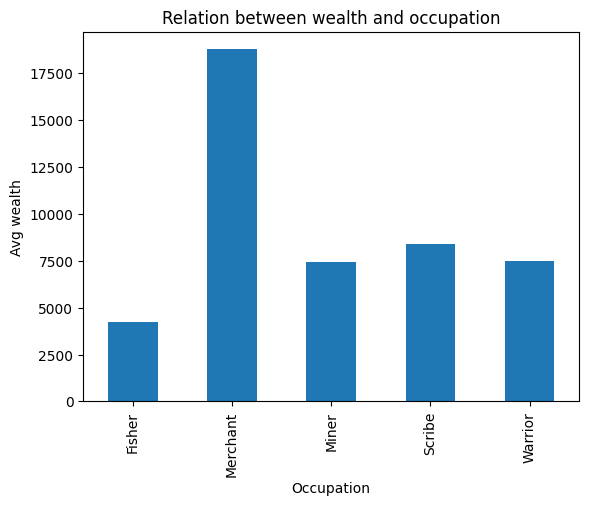

In [66]:
#Relation between wealth and occupation
c = df.groupby('Occupation')['Wealth_Index'].mean()
c.plot(kind = 'bar', ylabel = 'Avg wealth',title = 'Relation between wealth and occupation')

Text(0, 0.5, 'Count of Citizens')

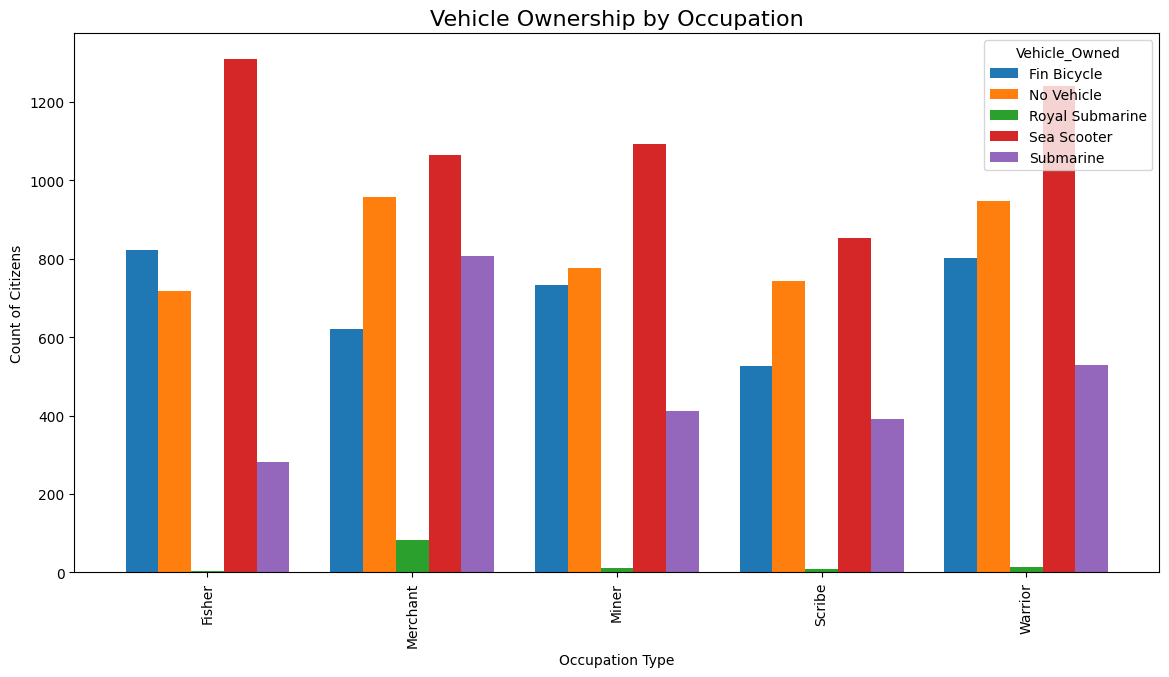

In [70]:
#Relation between Occupation and the vehicle owned
counts = df.groupby(['Occupation', 'Vehicle_Owned']).size().unstack(fill_value=0)
counts.plot(kind='bar', figsize=(14, 7), width=0.8)
plt.title('Vehicle Ownership by Occupation', fontsize=16)
plt.xlabel('Occupation Type')
plt.ylabel('Count of Citizens')

<Axes: xlabel='District_Name'>

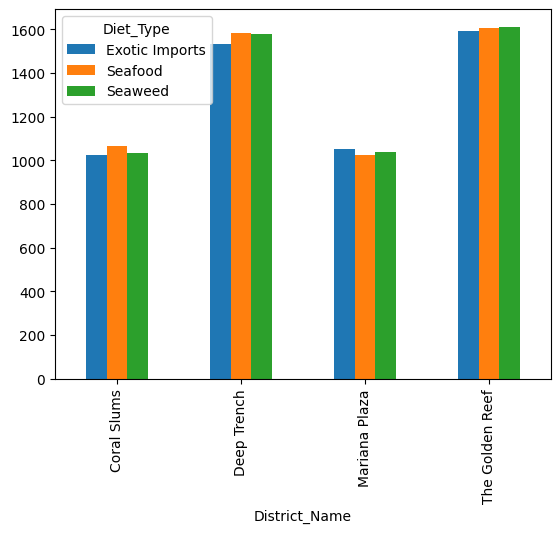

In [75]:
#District vs Diet
d = df.groupby(['District_Name','Diet_Type']).size().unstack(fill_value=0)
d.plot(kind = 'bar')

<Axes: title={'center': 'Relation between working district and wealth'}, xlabel='Work_District', ylabel='Avg Wealth of the person working in the district'>

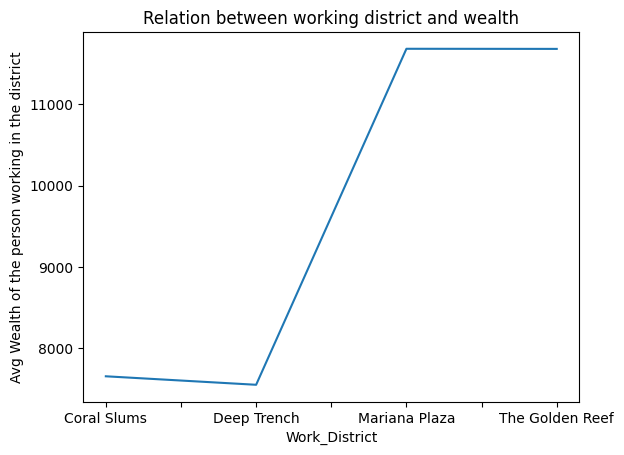

In [77]:
#work district vs wealth
e = df.groupby('Work_District')['Wealth_Index'].mean()
e.plot(ylabel = 'Avg Wealth of the person working in the district',title = 'Relation between working district and wealth')

<Axes: xlabel='Vehicle_Owned', ylabel='Wealth_Index'>

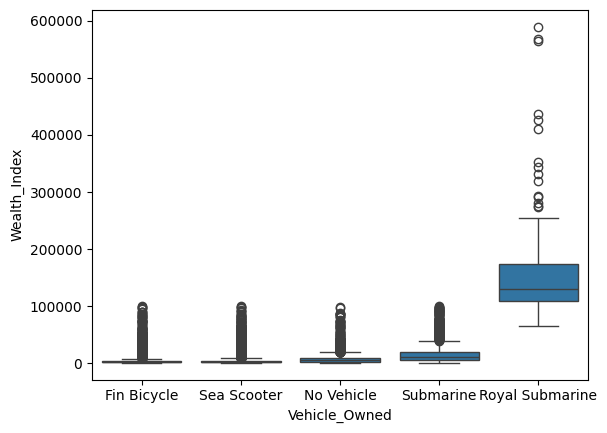

In [80]:
#vehicle owned vs wealth
sns.boxplot(data=df, x='Vehicle_Owned', y='Wealth_Index')

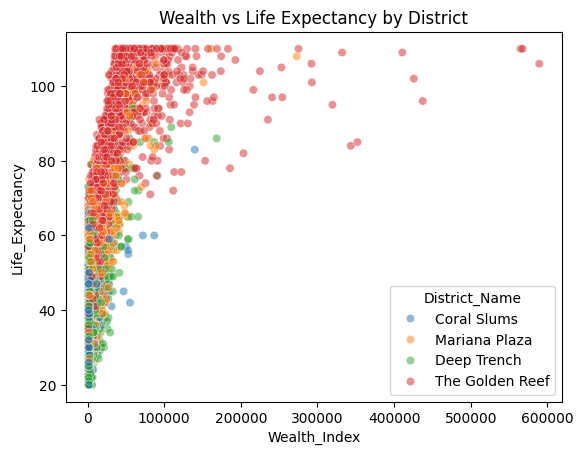

In [86]:
#wealth vs life expectancy (districtwise)
plt.figure()
sns.scatterplot(data=df, x='Wealth_Index', y='Life_Expectancy', hue='District_Name', alpha=0.5)
plt.title('Wealth vs Life Expectancy by District')
plt.show()

<Axes: xlabel='District_Name'>

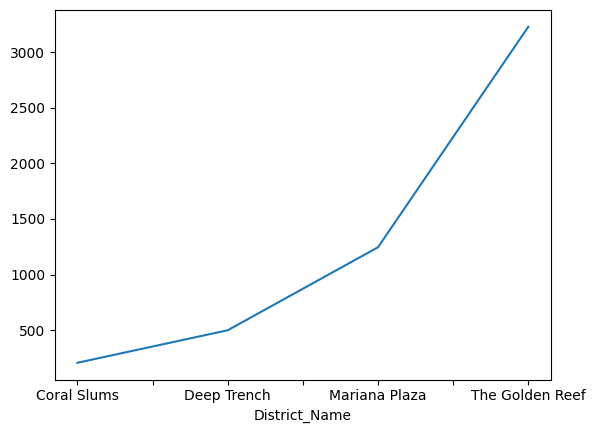

In [87]:
#district vs house size
f = df.groupby('District_Name')['House_Size_sq_ft'].mean()
f.plot(kind = 'line')
